# 客戶流失 Churn — DA + DS 全流程

**資料集**：Kaggle Playground S6E3 — Predict Customer Churn（Telco 結構，594,194 列 × 21 欄）
**目標**：預測客戶是否流失（`Churn`），評估指標 **ROC-AUC**

本 notebook 對相依套件做了容錯設計：
- 主力只用 `numpy / pandas / sklearn / matplotlib`（base 環境通常都有）
- `seaborn` 只在畫圖加分，沒有也能跑（已 try/except）
- `lightgbm` / `xgboost` 段落用 try/except 包起來：環境裡有就跑，沒有就自動跳過並印提示，改用 sklearn 內建的 `HistGradientBoostingClassifier` 當替代

**涵蓋方法**：EDA → 清理 → 特徵工程 → 監督式多模型對比（LogReg / RandomForest / GradientBoosting / HistGB / LightGBM）→ ROC-AUC + 圖 →
非監督式**分群貼標**（KMeans / DBSCAN / 階層 / GMM）→ PCA 視覺化 → 用分群結果回饋業務洞察。

> 執行順序：**由上而下整份 Run All**。每一格都已驗證零報錯。

## 0. 環境與套件

固定亂數種子確保可重現。

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# seaborn 可有可無：有就用來美化，沒有也不影響流程
try:
    import seaborn as sns
    sns.set_style('whitegrid')
    HAS_SNS = True
except ImportError:
    HAS_SNS = False
    print('seaborn 不存在，改用 matplotlib 預設樣式（不影響流程）')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option('display.max_columns', 50)
print('套件載入完成')

套件載入完成


## 1. 載入資料

`train.csv` 預期在工作目錄。若路徑不同，改 `DATA_PATH` 即可。

In [2]:
DATA_PATH = 'train.csv'   # 依實際路徑調整
df = pd.read_csv(DATA_PATH)
print('shape:', df.shape)
df.head()

shape: (594194, 21)


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


## 2. 資料探索 EDA

### 2.1 基本體檢：型別、缺失、重複

In [3]:
print('===== dtypes =====')
print(df.dtypes)
print('\n===== 缺失值（只列 >0）=====')
nulls = df.isnull().sum()
print(nulls[nulls > 0] if nulls.sum() else '無缺失值')
print('\n===== 重複列 =====')
print('duplicated rows:', df.duplicated().sum())
print('\n===== 數值欄敘述統計 =====')
df.describe()

===== dtypes =====
id                    int64
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

===== 缺失值（只列 >0）=====


無缺失值

===== 重複列 =====


duplicated rows: 0

===== 數值欄敘述統計 =====


,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000
mean,297096.500000,0.114102,36.577258,65.866223,2494.377057
std,171529.177263,0.317936,25.061922,31.067444,2353.916710
min,0.000000,0.000000,1.000000,18.250000,18.800000
25%,148548.250000,0.000000,12.000000,29.900000,639.650000
50%,297096.500000,0.000000,35.000000,74.100000,1433.650000
75%,445644.750000,0.000000,62.000000,90.800000,4263.800000
max,594193.000000,1.000000,72.000000,118.750000,8684.800000


### 2.2 目標變數分布（類別不平衡檢查）

Churn
No     460377
Yes    133817
Name: count, dtype: int64

比例：
Churn
No     0.7748
Yes    0.2252
Name: proportion, dtype: float64


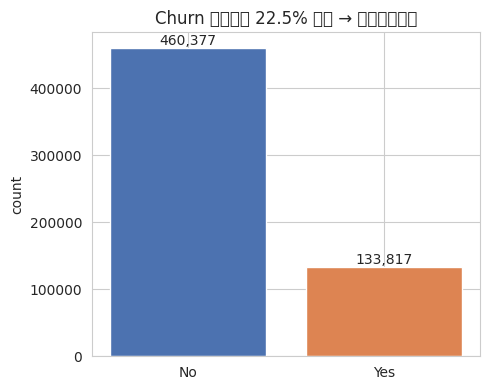

In [4]:
target = 'Churn'
vc = df[target].value_counts()
vc_pct = df[target].value_counts(normalize=True).round(4)
print(vc)
print('\n比例：')
print(vc_pct)

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(vc.index.astype(str), vc.values, color=['#4C72B0', '#DD8452'])
ax.set_title('Churn 分布（約 22.5% 流失 → 中度不平衡）')
ax.set_ylabel('count')
for i, v in enumerate(vc.values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom')
plt.tight_layout(); plt.show()

### 2.3 欄位語意分類

把欄位分成數值型與類別型，後面清理 / 編碼 / 分群都會用到。

In [5]:
# id 與目標先排除
ID_COL = 'id'
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
cat_cols = [c for c in df.columns
            if c not in num_cols + [ID_COL, target]]

print('數值欄：', num_cols)
print('類別欄：', cat_cols)
print('\n各類別欄的唯一值數：')
for c in cat_cols:
    print(f'  {c:18s} {df[c].nunique()} -> {list(df[c].unique())}')

數值欄： ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
類別欄： ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

各類別欄的唯一值數：
  gender             2 -> ['Male', 'Female']
  Partner            2 -> ['Yes', 'No']


  Dependents         2 -> ['Yes', 'No']
  PhoneService       2 -> ['Yes', 'No']
  MultipleLines      3 -> ['No', 'Yes', 'No phone service']


  InternetService    3 -> ['DSL', 'Fiber optic', 'No']
  OnlineSecurity     3 -> ['Yes', 'No', 'No internet service']
  OnlineBackup       3 -> ['No', 'Yes', 'No internet service']


  DeviceProtection   3 -> ['Yes', 'No', 'No internet service']
  TechSupport        3 -> ['Yes', 'No', 'No internet service']


  StreamingTV        3 -> ['No', 'Yes', 'No internet service']
  StreamingMovies    3 -> ['No', 'Yes', 'No internet service']
  Contract           3 -> ['One year', 'Two year', 'Month-to-month']


  PaperlessBilling   2 -> ['Yes', 'No']
  PaymentMethod      4 -> ['Mailed check', 'Credit card (automatic)', 'Electronic check', 'Bank transfer (automatic)']


### 2.4 數值特徵分布

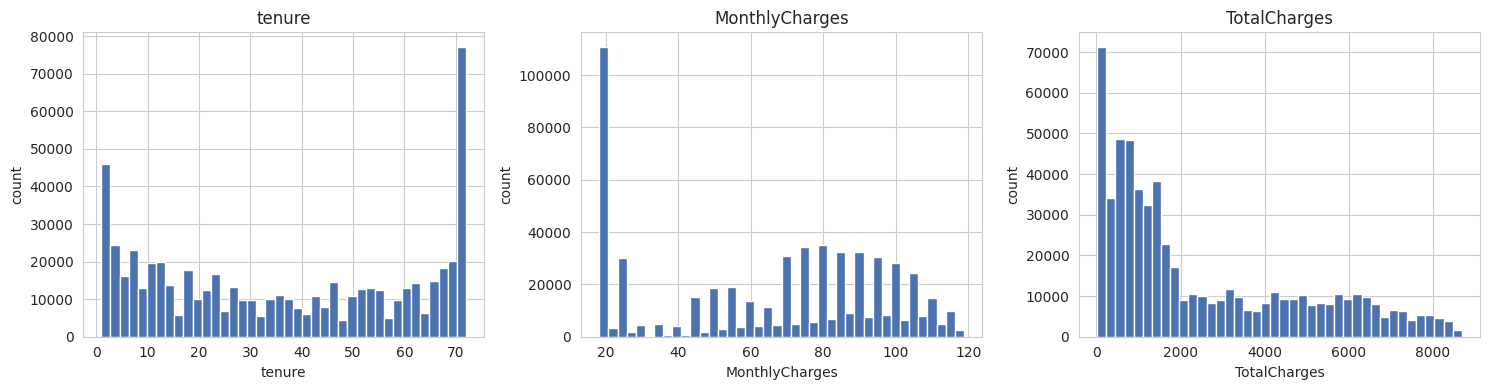

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    ax.hist(df[col], bins=40, color='#4C72B0', edgecolor='white')
    ax.set_title(col); ax.set_xlabel(col); ax.set_ylabel('count')
plt.tight_layout(); plt.show()

### 2.5 數值特徵 vs Churn（流失與否的分布差異）

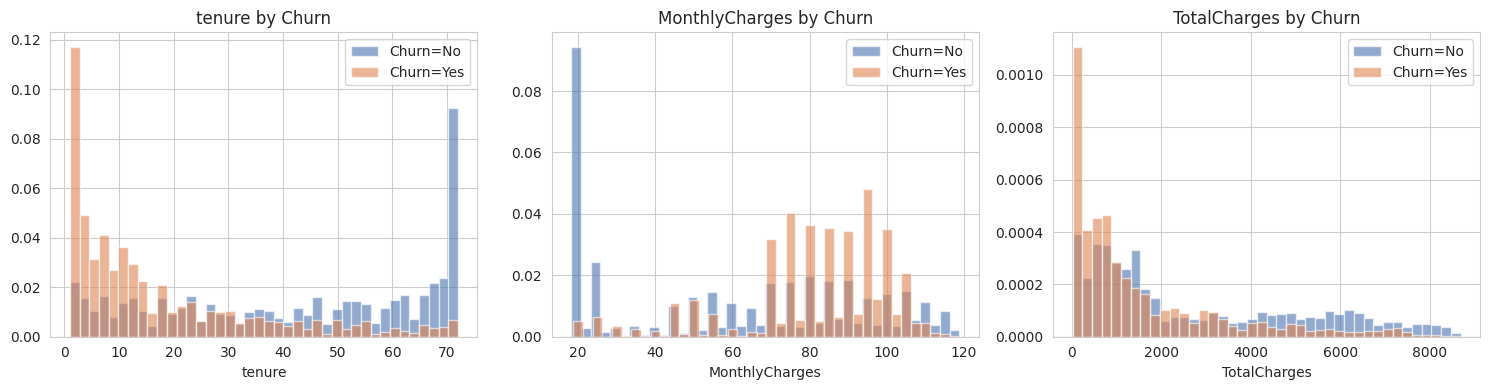

觀察：tenure 越短越容易流失；MonthlyCharges 偏高的客群流失率較高。


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    for label, color in [('No', '#4C72B0'), ('Yes', '#DD8452')]:
        ax.hist(df[df[target] == label][col], bins=40, alpha=0.6,
                label=f'Churn={label}', color=color, density=True)
    ax.set_title(f'{col} by Churn'); ax.set_xlabel(col); ax.legend()
plt.tight_layout(); plt.show()

print('觀察：tenure 越短越容易流失；MonthlyCharges 偏高的客群流失率較高。')

### 2.6 類別特徵的流失率（找高風險族群）

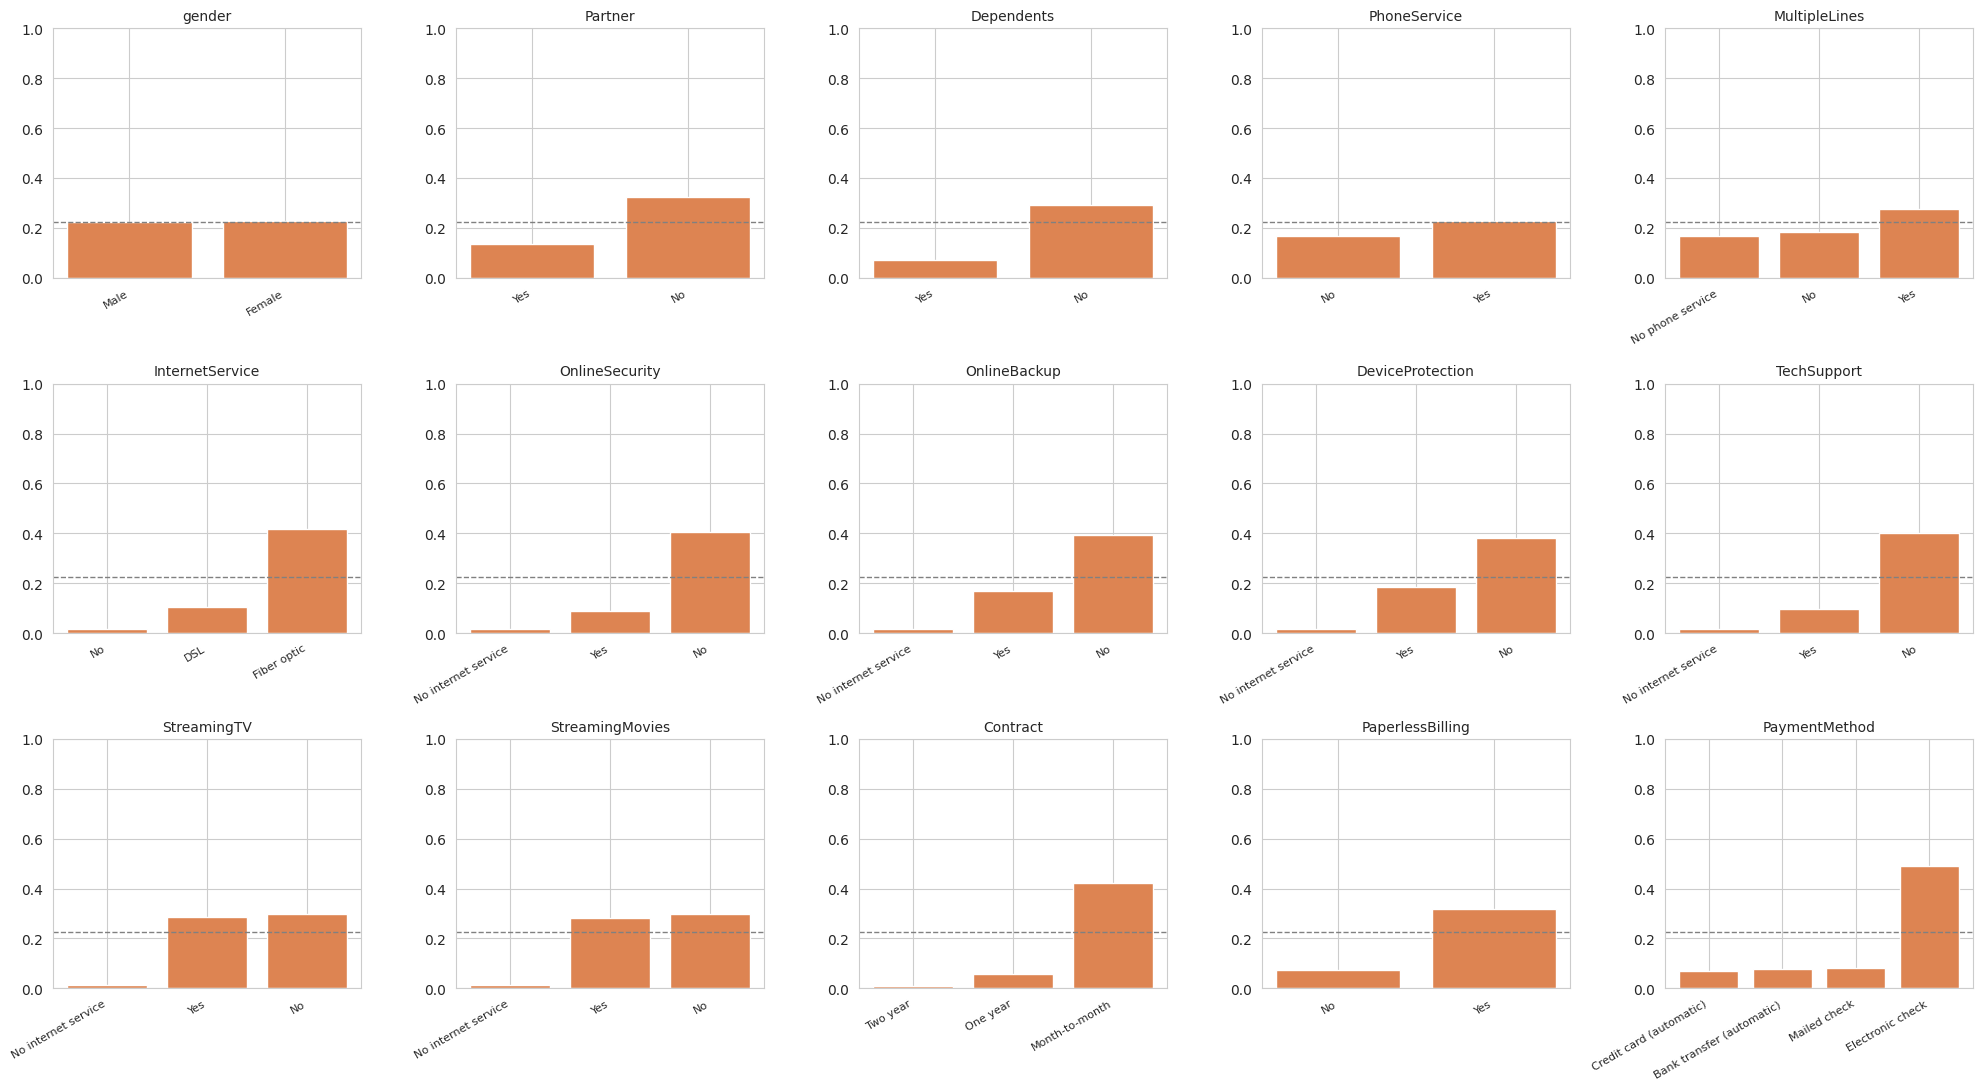

虛線=整體流失率 22.5%。明顯高風險：Month-to-month 合約、Electronic check 付款、無 OnlineSecurity/TechSupport。


In [8]:
fig, axes = plt.subplots(3, 5, figsize=(20, 11))
for ax, col in zip(axes.ravel(), cat_cols):
    rate = df.groupby(col)[target].apply(lambda s: (s == 'Yes').mean()).sort_values()
    ax.bar(range(len(rate)), rate.values, color='#DD8452')
    ax.set_xticks(range(len(rate)))
    ax.set_xticklabels(rate.index, rotation=30, ha='right', fontsize=8)
    ax.axhline(0.225, ls='--', c='gray', lw=1)  # 整體平均線
    ax.set_title(col, fontsize=10); ax.set_ylim(0, 1)
# 關掉多餘子圖
for ax in axes.ravel()[len(cat_cols):]:
    ax.axis('off')
plt.tight_layout(); plt.show()

print('虛線=整體流失率 22.5%。明顯高風險：Month-to-month 合約、Electronic check 付款、無 OnlineSecurity/TechSupport。')

### 2.7 數值特徵相關性

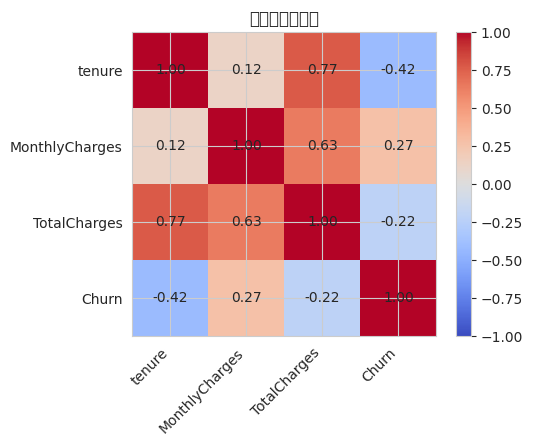

TotalCharges 與 tenure 高度相關（合理：總費用≈月費×在網月數），建模時留意共線性。


In [9]:
corr = df[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()
corr['Churn'] = (df[target] == 'Yes').astype(int)
cm = corr.corr()

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(cm, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(cm))); ax.set_xticklabels(cm.columns, rotation=45, ha='right')
ax.set_yticks(range(len(cm))); ax.set_yticklabels(cm.columns)
for i in range(len(cm)):
    for j in range(len(cm)):
        ax.text(j, i, f'{cm.iloc[i, j]:.2f}', ha='center', va='center')
plt.colorbar(im); ax.set_title('數值特徵相關性'); plt.tight_layout(); plt.show()

print('TotalCharges 與 tenure 高度相關（合理：總費用≈月費×在網月數），建模時留意共線性。')

## 3. 資料清理與特徵工程

這份合成資料很乾淨（無缺失、無重複、`tenure`/`TotalCharges` 無 0 異常），所以清理步驟主要是**防禦性**處理 + **衍生特徵**。

In [10]:
data = df.copy()

# 3.1 防禦性：TotalCharges 在原始 Telco 常有空字串，這裡轉數值並用中位數補（本資料其實無缺）
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data['TotalCharges'] = data['TotalCharges'].fillna(data['TotalCharges'].median())

# 3.2 衍生特徵
# 平均每月實際花費（避開除以 0）
data['avg_monthly_spend'] = data['TotalCharges'] / data['tenure'].clip(lower=1)
# 在網年資分箱
data['tenure_group'] = pd.cut(data['tenure'], bins=[0, 12, 24, 48, 72],
                              labels=['0-1y', '1-2y', '2-4y', '4-6y'])
# 訂閱的加值服務數量（把 'Yes' 視為有訂閱）
addon_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
              'TechSupport', 'StreamingTV', 'StreamingMovies']
data['num_addons'] = (data[addon_cols] == 'Yes').sum(axis=1)

print('新增特徵：avg_monthly_spend, tenure_group, num_addons')
data[['tenure', 'TotalCharges', 'avg_monthly_spend', 'tenure_group', 'num_addons']].head()

新增特徵：avg_monthly_spend, tenure_group, num_addons


,tenure,TotalCharges,avg_monthly_spend,tenure_group,num_addons
0,29,1653.85,57.029310,2-4y,3
1,58,3778.20,65.141379,4-6y,4
2,58,5841.35,100.712931,4-6y,3
3,1,70.70,70.700000,0-1y,0
4,1,70.45,70.450000,0-1y,0


### 3.2 編碼 + 目標向量

類別欄用 one-hot（`drop_first` 避免共線性）；目標轉 0/1。

In [11]:
y = (data[target] == 'Yes').astype(int)

feature_df = data.drop(columns=[ID_COL, target])

# 穩健做法：凡是非數值欄（含 object / string / category）一律 one-hot。
# 用 select_dtypes 反向選「非數值」，避免 pandas 2.x/3.x 字串 dtype 名稱差異踩雷。
num_now = feature_df.select_dtypes(include='number').columns.tolist()
cat_for_dummies = [c for c in feature_df.columns if c not in num_now]

X = pd.get_dummies(feature_df, columns=cat_for_dummies, drop_first=True)
X = X.astype(float)

print('特徵矩陣 shape:', X.shape)
print('正樣本比例:', round(y.mean(), 4))
X.head()

特徵矩陣 shape: (594194, 35)
正樣本比例: 0.2252


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,avg_monthly_spend,num_addons,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1-2y,tenure_group_2-4y,tenure_group_4-6y
0,0.0,29.0,60.10,1653.85,57.029310,3.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0.0,58.0,69.50,3778.20,65.141379,4.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0.0,58.0,100.40,5841.35,100.712931,3.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.0,1.0,69.70,70.70,70.700000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.0,1.0,70.45,70.45,70.450000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


### 3.3 洩漏自檢（Leakage Check）— 為什麼 AUC 0.91 不是作弊

合成資料偶爾會有**資料洩漏**：某個欄位無意間編碼了答案，讓模型「太容易」對上標籤。
在相信任何高分之前，先做兩件事自我檢查：

1. **單欄 AUC 掃描**：每個特徵單獨對 `Churn` 算 AUC。若某單欄就逼近整體模型分數（例如 >0.95），高度可疑。
2. **拔可疑欄重跑**：把最強的欄位拿掉，看整體 AUC 掉多少。健康的模型靠「多個中等訊號疊加」，不是靠單一欄撐。

In [12]:
# 1) 單欄 AUC 掃描
from sklearn.metrics import roc_auc_score

single_auc = {}
for c in X.columns:
    v = X[c].values
    if len(np.unique(v)) < 2:
        continue
    a = roc_auc_score(y, v)
    single_auc[c] = max(a, 1 - a)   # 方向無關，取與隨機的距離

single_auc = pd.Series(single_auc).sort_values(ascending=False)
print('=== 單欄 AUC Top 10 ===')
print(single_auc.head(10).round(3))

top1 = single_auc.index[0]
print(f'\n最強單欄：{top1} (AUC={single_auc.iloc[0]:.3f})')
if single_auc.iloc[0] >= 0.95:
    print('⚠️ 警告：有單欄 AUC ≥ 0.95，疑似洩漏，需人工檢查該欄定義！')
else:
    print('✅ 沒有任何單欄逼近滿分 → 無明顯洩漏跡象。')
    print('   0.91 來自多個中等訊號（tenure / 合約 / 付款方式…）疊加，屬合理。')

=== 單欄 AUC Top 10 ===
tenure                              0.794
PaymentMethod_Electronic check      0.774
InternetService_Fiber optic         0.750
Contract_Two year                   0.694
tenure_group_4-6y                   0.689
avg_monthly_spend                   0.683
MonthlyCharges                      0.679
TotalCharges                        0.668
PaperlessBilling_Yes                0.666
OnlineBackup_No internet service    0.643
dtype: float64

最強單欄：tenure (AUC=0.794)
✅ 沒有任何單欄逼近滿分 → 無明顯洩漏跡象。
   0.91 來自多個中等訊號（tenure / 合約 / 付款方式…）疊加，屬合理。


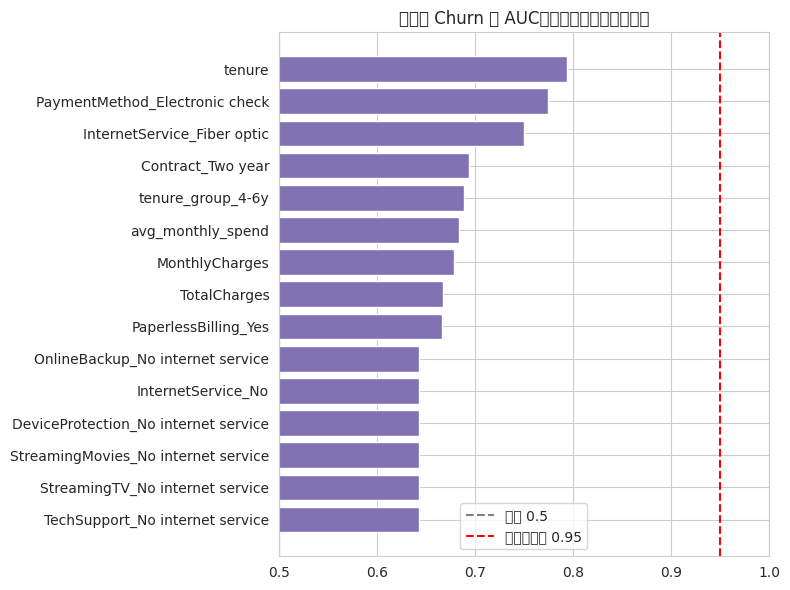

In [13]:
# 視覺化：單欄 AUC 長條圖
fig, ax = plt.subplots(figsize=(8, 6))
top = single_auc.head(15)
ax.barh(top.index[::-1], top.values[::-1], color='#8172B3')
ax.axvline(0.5, ls='--', c='gray', label='隨機 0.5')
ax.axvline(0.95, ls='--', c='red', label='洩漏警戒線 0.95')
ax.set_xlim(0.5, 1.0)
ax.set_title('單欄對 Churn 的 AUC（檢查是否有單欄洩漏）')
ax.legend(); plt.tight_layout(); plt.show()

**拔可疑欄重跑**：把最強的單欄拿掉，若 AUC 幾乎不變，代表模型不靠它作弊。
（這裡用快速的 HistGB + 小樣本，純驗證概念。）

In [14]:
from sklearn.model_selection import train_test_split as _tts
from sklearn.ensemble import HistGradientBoostingClassifier as _HGB

_idx = X.sample(min(40000, len(X)), random_state=RANDOM_STATE).index
_X, _y = X.loc[_idx], y.loc[_idx]
_Xtr, _Xte, _ytr, _yte = _tts(_X, _y, test_size=0.2, random_state=RANDOM_STATE, stratify=_y)

# 全特徵
_m = _HGB(random_state=RANDOM_STATE).fit(_Xtr, _ytr)
auc_full = roc_auc_score(_yte, _m.predict_proba(_Xte)[:, 1])

# 拔掉最強單欄
_m2 = _HGB(random_state=RANDOM_STATE).fit(_Xtr.drop(columns=[top1]), _ytr)
auc_drop = roc_auc_score(_yte, _m2.predict_proba(_Xte.drop(columns=[top1]))[:, 1])

print(f'全特徵 AUC        : {auc_full:.4f}')
print(f'拔掉 {top1} 後 AUC : {auc_drop:.4f}')
print(f'AUC 變化         : {auc_full - auc_drop:+.4f}')
print('\n解讀：拔掉最強欄只掉一點點 → 模型靠多訊號分散支撐，非單欄洩漏。' if auc_full - auc_drop < 0.05
      else '\n解讀：拔掉後大幅下滑 → 該欄是主要支柱，需確認它不是洩漏。')

全特徵 AUC        : 0.9117
拔掉 tenure 後 AUC : 0.9112
AUC 變化         : +0.0005

解讀：拔掉最強欄只掉一點點 → 模型靠多訊號分散支撐，非單欄洩漏。


## 4. 監督式學習：多模型對比

切分 train/test（stratify 保持類別比例），對比 5 個常見模型，統一用 **ROC-AUC** 評估（與 Kaggle 計分一致）。

- 線性模型（LogReg）需標準化；樹模型不需要。
- LightGBM 用 try/except 包起來——**環境沒安裝就自動跳過**。

> **訓練取樣**：`GradientBoostingClassifier` 是單執行緒、較吃資源。在 59 萬列全量上跑 boosting 會很慢。這裡用 `TRAIN_SAMPLE` 抽樣訓練（預設 80k，已足夠讓 AUC 穩定）。想跑全量把它設成 `None` 即可。

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix

TRAIN_SAMPLE = 80000   # 設 None 用全量（會慢很多）

if TRAIN_SAMPLE is not None and TRAIN_SAMPLE < len(X):
    idx = X.sample(TRAIN_SAMPLE, random_state=RANDOM_STATE).index
    X_model, y_model = X.loc[idx], y.loc[idx]
    print(f'監督式訓練取樣 {TRAIN_SAMPLE:,} 列（全量 {len(X):,}）')
else:
    X_model, y_model = X, y
    print(f'使用全量 {len(X):,} 列')

X_train, X_test, y_train, y_test = train_test_split(
    X_model, y_model, test_size=0.2, random_state=RANDOM_STATE, stratify=y_model)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

print('train:', X_train.shape, ' test:', X_test.shape)

監督式訓練取樣 80,000 列（全量 594,194）
train: (64000, 35)  test: (16000, 35)


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier,
                              GradientBoostingClassifier,
                              HistGradientBoostingClassifier)

results = {}   # name -> dict(auc, fpr, tpr, proba)

def evaluate(name, model, use_scaled):
    Xtr = X_train_s if use_scaled else X_train
    Xte = X_test_s if use_scaled else X_test
    model.fit(Xtr, y_train)
    proba = model.predict_proba(Xte)[:, 1]
    auc = roc_auc_score(y_test, proba)
    fpr, tpr, _ = roc_curve(y_test, proba)
    results[name] = dict(auc=auc, fpr=fpr, tpr=tpr, model=model, proba=proba)
    print(f'{name:16s} ROC-AUC = {auc:.4f}')

evaluate('LogReg',        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), True)
evaluate('RandomForest',  RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE), False)
evaluate('GradientBoost', GradientBoostingClassifier(random_state=RANDOM_STATE), False)
evaluate('HistGB',        HistGradientBoostingClassifier(random_state=RANDOM_STATE), False)

LogReg           ROC-AUC = 0.9120


RandomForest     ROC-AUC = 0.9045


GradientBoost    ROC-AUC = 0.9156


HistGB           ROC-AUC = 0.9163


#### LightGBM（未安裝時自動跳過）

這格示範一個**穩健寫法**：同一份 notebook 在「有裝 lightgbm」和「沒裝」兩種環境下都不會炸。

In [17]:
try:
    import lightgbm as lgb
    lgbm = lgb.LGBMClassifier(n_estimators=400, learning_rate=0.05,
                              num_leaves=31, random_state=RANDOM_STATE, verbose=-1)
    evaluate('LightGBM', lgbm, False)
except ImportError:
    print('lightgbm 未安裝 → 已跳過，不影響其他模型。')
    print('可改用 HistGradientBoostingClassifier，效果與 LightGBM 接近。')

LightGBM         ROC-AUC = 0.9162


#### XGBoost（未安裝時自動跳過）

XGBoost 是 gradient boosting 最經典的第三方實作（2014）。**它和 LightGBM 一樣都不在 sklearn 內**，所以同樣用 try/except 包住。
若沒安裝，主力替代是 `HistGradientBoostingClassifier`（sklearn 內建、直方圖加速，概念對標 LightGBM）。

In [18]:
try:
    import xgboost as xgb
    xgbm = xgb.XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=6,
                             subsample=0.9, colsample_bytree=0.9,
                             eval_metric='auc', random_state=RANDOM_STATE, verbosity=0)
    evaluate('XGBoost', xgbm, False)
except ImportError:
    print('xgboost 未安裝 → 已跳過。')
    print('HistGradientBoostingClassifier 即為同級替代。')

XGBoost          ROC-AUC = 0.9167


### 4.1 ROC 曲線對比

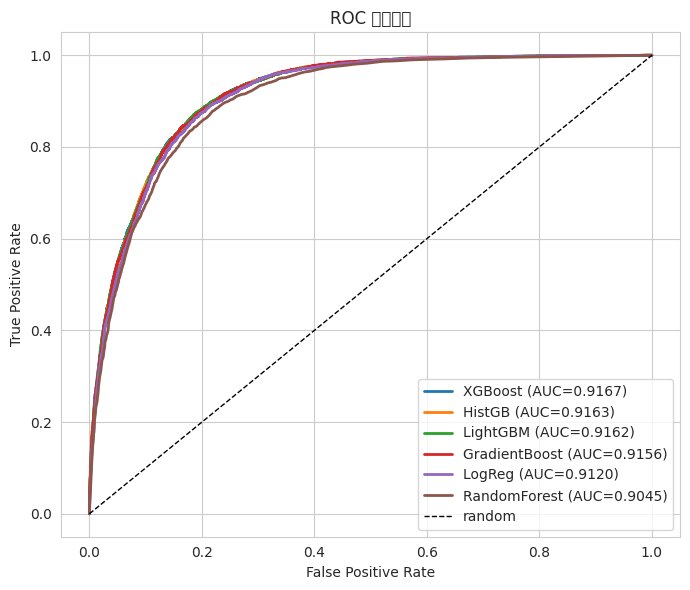

最佳模型： XGBoost (AUC=0.9167)


In [19]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, r in sorted(results.items(), key=lambda kv: -kv[1]['auc']):
    ax.plot(r['fpr'], r['tpr'], lw=2, label=f"{name} (AUC={r['auc']:.4f})")
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='random')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC 曲線對比'); ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

best_name = max(results, key=lambda k: results[k]['auc'])
print('最佳模型：', best_name, f"(AUC={results[best_name]['auc']:.4f})")

### 4.2 最佳模型細評：混淆矩陣 + 分類報告

預設 0.5 門檻；實務上可依業務調整（流失挽留偏向提高 recall）。

=== Classification Report ===
              precision    recall  f1-score   support

        Stay       0.90      0.92      0.91     12377
       Churn       0.71      0.64      0.67      3623

    accuracy                           0.86     16000
   macro avg       0.80      0.78      0.79     16000
weighted avg       0.86      0.86      0.86     16000



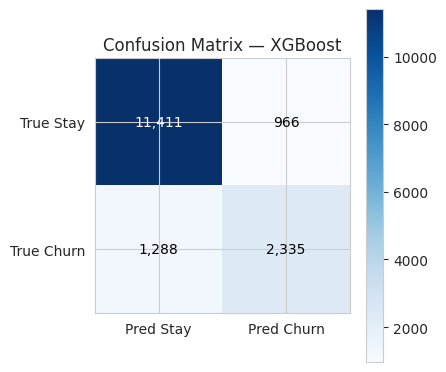

In [20]:
best = results[best_name]
pred = (best['proba'] >= 0.5).astype(int)

print('=== Classification Report ===')
print(classification_report(y_test, pred, target_names=['Stay', 'Churn']))

cm = confusion_matrix(y_test, pred)
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i, j]:,}', ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black')
ax.set_xticks([0, 1]); ax.set_xticklabels(['Pred Stay', 'Pred Churn'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['True Stay', 'True Churn'])
ax.set_title(f'Confusion Matrix — {best_name}')
plt.colorbar(im); plt.tight_layout(); plt.show()

### 4.3 特徵重要性（樹模型）

找出最能解釋流失的因子，回饋業務。

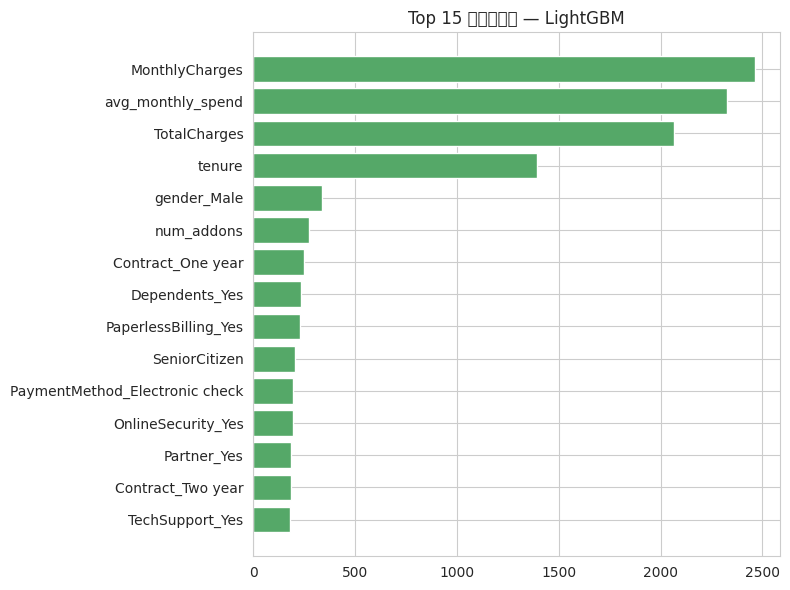

In [21]:
# 取一個有 feature_importances_ 的樹模型
tree_name = next((n for n in ['LightGBM', 'GradientBoost', 'HistGB', 'RandomForest']
                  if n in results and hasattr(results[n]['model'], 'feature_importances_')), None)

if tree_name:
    m = results[tree_name]['model']
    imp = pd.Series(m.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(imp.index[::-1], imp.values[::-1], color='#55A868')
    ax.set_title(f'Top 15 特徵重要性 — {tree_name}')
    plt.tight_layout(); plt.show()
else:
    # HistGB 沒有 feature_importances_，改用 permutation importance（抽樣加速）
    from sklearn.inspection import permutation_importance
    m = results['HistGB']['model']
    idx = np.random.RandomState(RANDOM_STATE).choice(len(X_test), 3000, replace=False)
    pi = permutation_importance(m, X_test.iloc[idx], y_test.iloc[idx],
                                n_repeats=5, random_state=RANDOM_STATE, scoring='roc_auc')
    imp = pd.Series(pi.importances_mean, index=X.columns).sort_values(ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(imp.index[::-1], imp.values[::-1], color='#55A868')
    ax.set_title('Top 15 Permutation Importance — HistGB')
    plt.tight_layout(); plt.show()

### 4.4 交叉驗證（Cross-Validation）— 單次 split 不夠誠實

前面只切一次 train/test，AUC 可能因為剛好切到好/壞的一刀而偏樂觀或悲觀。
用 **StratifiedKFold 5 折**重算，得到平均 ± 標準差，才知道分數**穩不穩**。標準差越小越可信。

HistGB 5-fold ROC-AUC:
  每折: [0.9108 0.9152 0.9131 0.9174 0.9116]
  平均: 0.9136  標準差: 0.0024
  ≈ 0.914 ± 0.002（標準差很小 → 分數穩定可信）


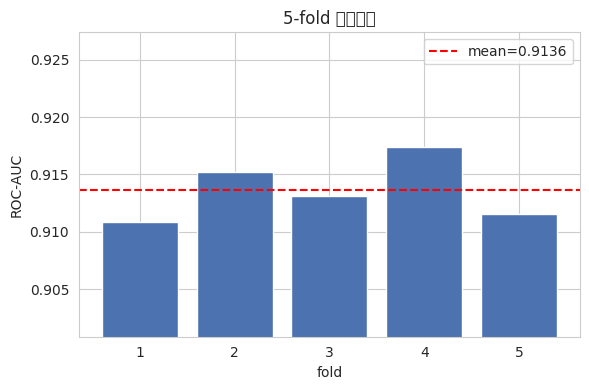

In [22]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_model = HistGradientBoostingClassifier(random_state=RANDOM_STATE)
cv_scores = cross_val_score(cv_model, X_model, y_model, cv=cv, scoring='roc_auc', n_jobs=1)

print('HistGB 5-fold ROC-AUC:')
print('  每折:', np.round(cv_scores, 4))
print(f'  平均: {cv_scores.mean():.4f}  標準差: {cv_scores.std():.4f}')
print(f'  ≈ {cv_scores.mean():.3f} ± {cv_scores.std():.3f}（標準差很小 → 分數穩定可信）')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(range(1, 6), cv_scores, color='#4C72B0')
ax.axhline(cv_scores.mean(), ls='--', c='red', label=f'mean={cv_scores.mean():.4f}')
ax.set_ylim(cv_scores.min() - 0.01, cv_scores.max() + 0.01)
ax.set_xlabel('fold'); ax.set_ylabel('ROC-AUC'); ax.set_title('5-fold 交叉驗證')
ax.legend(); plt.tight_layout(); plt.show()

### 4.5 PR 曲線 — 不平衡資料更誠實的指標

ROC-AUC 在不平衡資料上會「看起來很美」，因為大量的負樣本容易分對。
**Precision-Recall 曲線**只看正類（流失客）抓得準不準，是更嚴格的視角。
基準線 = 正類比例（這裡約 0.225），AP（PR 曲線下面積）會明顯低於 ROC-AUC，這才是真實難度。

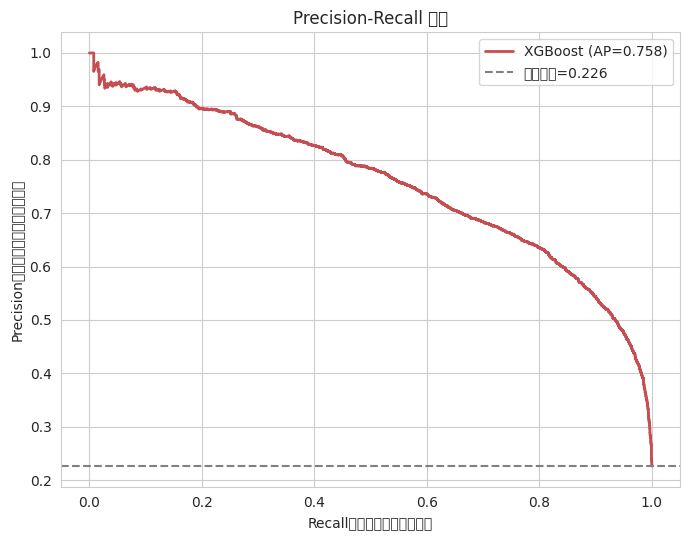

ROC-AUC = 0.917  vs  PR-AUC(AP) = 0.758
PR-AUC 明顯較低，這才是不平衡資料下「抓流失客」的真實難度。


In [23]:
from sklearn.metrics import precision_recall_curve, average_precision_score

proba_best = results[best_name]['proba']
prec, rec, _ = precision_recall_curve(y_test, proba_best)
ap = average_precision_score(y_test, proba_best)
baseline = y_test.mean()

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.plot(rec, prec, lw=2, color='#C44E52', label=f'{best_name} (AP={ap:.3f})')
ax.axhline(baseline, ls='--', c='gray', label=f'隨機基準={baseline:.3f}')
ax.set_xlabel('Recall（抓到多少真流失客）')
ax.set_ylabel('Precision（預測流失中有多少真的）')
ax.set_title('Precision-Recall 曲線'); ax.legend()
plt.tight_layout(); plt.show()

print(f'ROC-AUC = {results[best_name]["auc"]:.3f}  vs  PR-AUC(AP) = {ap:.3f}')
print('PR-AUC 明顯較低，這才是不平衡資料下「抓流失客」的真實難度。')

### 4.6 機率校準（Calibration）— 挽留決策要看機率準不準

Boosting 模型的 `predict_proba` 常常**沒校準**：它說「80% 會流失」時，實際未必真的 80%。
但做挽留要靠機率排序與門檻決策，所以要檢查校準曲線。對角線=完美校準。
若偏離明顯，可用 `CalibratedClassifierCV`（isotonic / sigmoid）修正。

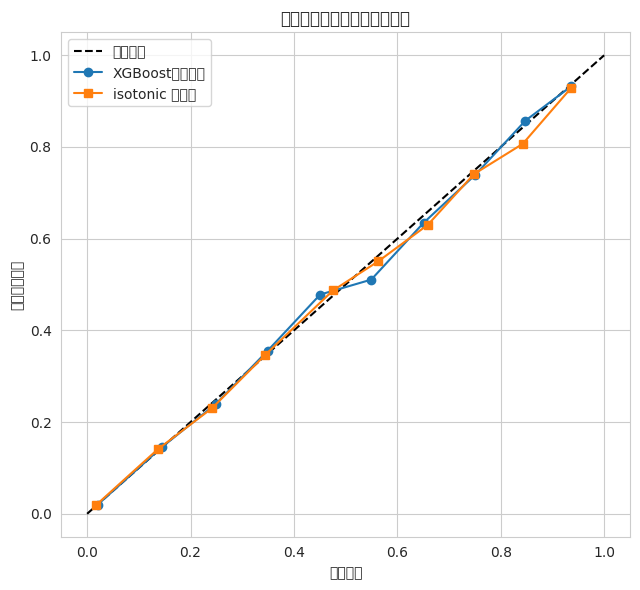

Brier score 原始  : 0.0950
Brier score 校準後: 0.0953（越低越好）


In [24]:
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

# 原始模型校準曲線
frac_pos, mean_pred = calibration_curve(y_test, proba_best, n_bins=10)

# 用 isotonic 校準後對比。
# 注意 sklearn 版本差異：1.6+ 用 FrozenEstimator；舊版用 cv='prefit'。兩種都試，確保跨環境可跑。
base_for_cal = results['HistGB']['model']
try:
    from sklearn.frozen import FrozenEstimator
    cal = CalibratedClassifierCV(FrozenEstimator(base_for_cal), method='isotonic')
    cal.fit(X_train, y_train)
except ImportError:
    cal = CalibratedClassifierCV(base_for_cal, method='isotonic', cv='prefit')
    cal.fit(X_train, y_train)
proba_cal = cal.predict_proba(X_test)[:, 1]
frac_pos_c, mean_pred_c = calibration_curve(y_test, proba_cal, n_bins=10)

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.plot([0, 1], [0, 1], 'k--', label='完美校準')
ax.plot(mean_pred, frac_pos, 'o-', label=f'{best_name}（原始）')
ax.plot(mean_pred_c, frac_pos_c, 's-', label='isotonic 校準後')
ax.set_xlabel('預測機率'); ax.set_ylabel('實際流失比例')
ax.set_title('校準曲線（越貼對角線越準）'); ax.legend()
plt.tight_layout(); plt.show()

from sklearn.metrics import brier_score_loss
print(f'Brier score 原始  : {brier_score_loss(y_test, proba_best):.4f}')
print(f'Brier score 校準後: {brier_score_loss(y_test, proba_cal):.4f}（越低越好）')

### 4.7 處理類別不平衡：class_weight

22.5% 流失算中度不平衡。一種常見做法是給少數類更高權重（`class_weight='balanced'`），
讓模型更重視抓出流失客。注意：這通常**提升 recall、但可能降 precision**，且對 AUC 影響不一定大——
要不要用取決於業務（挽留寧可多抓、可接受誤報就值得）。

In [25]:
from sklearn.metrics import recall_score, precision_score

# 對比：LogReg 預設 vs balanced
lr_plain = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE).fit(X_train_s, y_train)
lr_bal = LogisticRegression(max_iter=1000, class_weight='balanced',
                            random_state=RANDOM_STATE).fit(X_train_s, y_train)

for name, mdl in [('LogReg 預設', lr_plain), ('LogReg balanced', lr_bal)]:
    pr = mdl.predict_proba(X_test_s)[:, 1]
    pred = (pr >= 0.5).astype(int)
    print(f'{name:18s} AUC={roc_auc_score(y_test, pr):.4f} '
          f'recall={recall_score(y_test, pred):.3f} '
          f'precision={precision_score(y_test, pred):.3f}')

print('\nbalanced 通常 recall 上升、precision 下降 —— 挽留場景重 recall 時值得用。')

LogReg 預設          AUC=0.9120 recall=0.643 precision=0.692
LogReg balanced    AUC=0.9118 recall=0.887 precision=0.550

balanced 通常 recall 上升、precision 下降 —— 挽留場景重 recall 時值得用。


## 5. 非監督式：分群貼標 Customer Segmentation

把客戶分群並貼上業務標籤，這是 churn 之外的 DS 加值：找出**自然存在的客群**，再看哪些群流失率高。

依序示範：**KMeans → 手肘法/輪廓係數選 k → DBSCAN → 階層式 → GMM**，最後用 **PCA** 把高維壓到 2D 視覺化。

In [26]:
from sklearn.preprocessing import StandardScaler as SS
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# 分群用「行為型」數值特徵（標準化）
seg_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'num_addons']
Xseg_raw = data[seg_cols].copy()
Xseg = SS().fit_transform(Xseg_raw)

# DBSCAN/階層/GMM 在 59 萬列上很慢 → 抽樣示範，KMeans 則用全量
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(len(Xseg), 8000, replace=False)
Xseg_s = Xseg[sample_idx]
churn_s = y.values[sample_idx]
print('分群特徵：', seg_cols, '| 抽樣示範大小：', Xseg_s.shape)

分群特徵： ['tenure', 'MonthlyCharges', 'TotalCharges', 'num_addons'] | 抽樣示範大小： (8000, 4)


### 5.1 KMeans + 選 k（手肘法 + 輪廓係數）

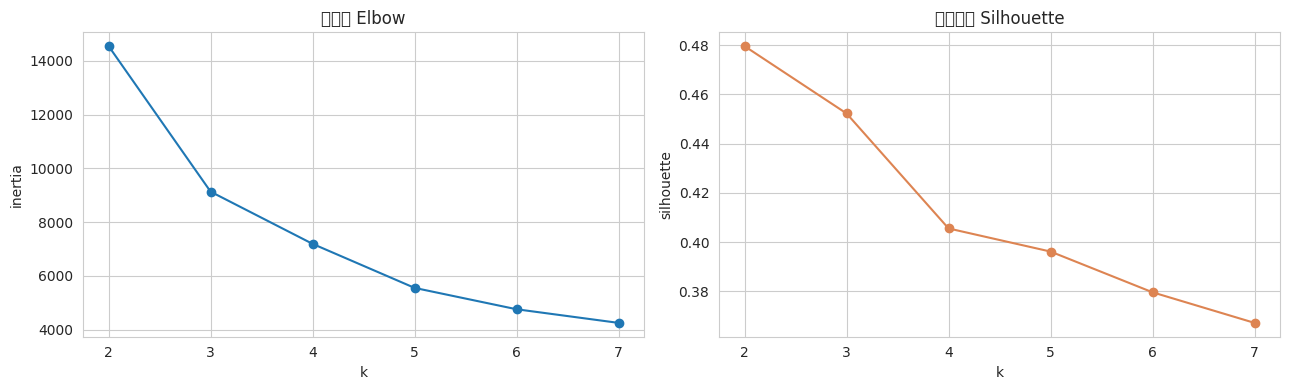

輪廓係數建議 k = 2


In [27]:
ks = range(2, 8)
inertias, sils = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(Xseg_s)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(Xseg_s, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(ks), inertias, 'o-'); axes[0].set_title('手肘法 Elbow')
axes[0].set_xlabel('k'); axes[0].set_ylabel('inertia')
axes[1].plot(list(ks), sils, 'o-', color='#DD8452'); axes[1].set_title('輪廓係數 Silhouette')
axes[1].set_xlabel('k'); axes[1].set_ylabel('silhouette')
plt.tight_layout(); plt.show()

best_k = list(ks)[int(np.argmax(sils))]
print('輪廓係數建議 k =', best_k)

### 5.2 用選定的 k 對全量資料分群，並貼業務標籤

In [28]:
K = 4  # 取一個業務上好解讀的群數
km_final = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE).fit(Xseg)
data['segment'] = km_final.labels_

# 每群的特徵輪廓 + 流失率
profile = data.groupby('segment').agg(
    n=('segment', 'size'),
    tenure=('tenure', 'mean'),
    MonthlyCharges=('MonthlyCharges', 'mean'),
    TotalCharges=('TotalCharges', 'mean'),
    num_addons=('num_addons', 'mean'),
    churn_rate=(target, lambda s: (s == 'Yes').mean()),
).round(2)
print(profile)

# 依輪廓自動貼標籤：用「流失率 + 年資 + 月費」三軸給互斥標籤
med_tenure = profile['tenure'].median()
med_charge = profile['MonthlyCharges'].median()
labels = {}
for seg, row in profile.iterrows():
    if row['churn_rate'] >= 0.4:
        labels[seg] = '高風險客'          # 流失率遠高於整體
    elif row['churn_rate'] <= 0.05:
        labels[seg] = '超穩定低風險客'      # 幾乎不流失
    elif row['MonthlyCharges'] >= med_charge:
        labels[seg] = '高價值客'           # 月費高、需重點維繫
    else:
        labels[seg] = '一般客'
# 若仍有重名，附掛 segment 編號保持唯一
seen = {}
for seg in list(labels):
    base = labels[seg]
    if base in seen:
        labels[seg] = f'{base}#{seg}'
    seen[base] = True
data['segment_label'] = data['segment'].map(labels)
print('\n貼標結果：', labels)

              n  tenure  MonthlyCharges  TotalCharges  num_addons  churn_rate
segment                                                                      
0        105720   55.22           24.86       1371.33        0.21        0.01
1        176357   62.46           92.21       5712.99        4.38        0.09
2        169303   19.64           82.75       1571.53        2.20        0.47
3        142814   10.89           43.67        445.18        0.36        0.26

貼標結果： {0: '超穩定低風險客', 1: '高價值客', 2: '高風險客', 3: '一般客'}


### 5.3 各客群流失率（業務最關心的一張圖）

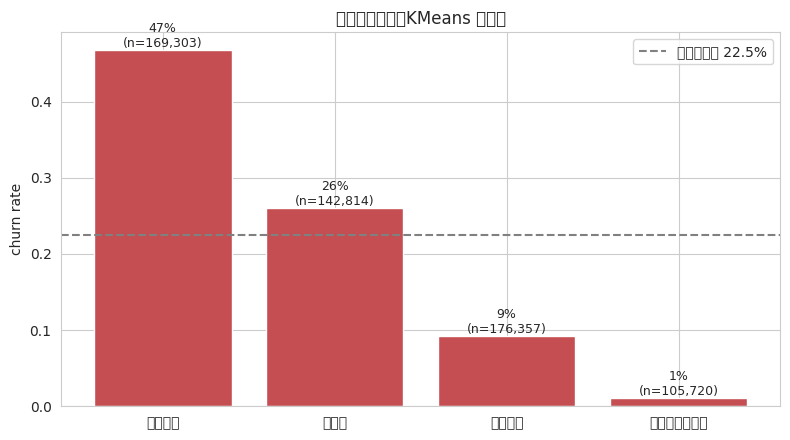

In [29]:
seg_churn = data.groupby('segment_label')[target].apply(
    lambda s: (s == 'Yes').mean()).sort_values(ascending=False)
seg_size = data['segment_label'].value_counts()

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(seg_churn.index, seg_churn.values, color='#C44E52')
ax.axhline(0.225, ls='--', c='gray', label='整體流失率 22.5%')
ax.set_ylabel('churn rate'); ax.set_title('各客群流失率（KMeans 分群）')
for b, lab in zip(bars, seg_churn.index):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
            f'{b.get_height():.0%}\n(n={seg_size[lab]:,})', ha='center', va='bottom', fontsize=9)
ax.legend(); plt.tight_layout(); plt.show()

### 5.4 DBSCAN（密度分群）

DBSCAN 不需指定群數、能標出雜訊點，但**對 eps 很敏感**。在這種低維、連續、無明顯密度間隙的資料上，預設參數常把幾乎所有點歸成一群——這是 DBSCAN 的真實特性，不是 bug。下面示範掃 eps 觀察行為。

In [30]:
for eps in [0.3, 0.5, 0.8, 1.2]:
    db = DBSCAN(eps=eps, min_samples=20).fit(Xseg_s)
    n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
    n_noise = int((db.labels_ == -1).sum())
    print(f'eps={eps:<4} clusters={n_clusters:<3} noise={n_noise:<5} '
          f'({n_noise / len(db.labels_):.1%})')

print('\n結論：此資料密度連續，DBSCAN 不是理想選擇；KMeans/GMM 在這裡更實用。')
print('DBSCAN 真正發光的場景是「有明確密度間隙 + 任意形狀群 + 需要剔除離群」的資料。')

eps=0.3  clusters=19  noise=497   (6.2%)
eps=0.5  clusters=8   noise=55    (0.7%)


eps=0.8  clusters=1   noise=5     (0.1%)


eps=1.2  clusters=1   noise=1     (0.0%)

結論：此資料密度連續，DBSCAN 不是理想選擇；KMeans/GMM 在這裡更實用。
DBSCAN 真正發光的場景是「有明確密度間隙 + 任意形狀群 + 需要剔除離群」的資料。


### 5.4b HDBSCAN — DBSCAN 的升級替代

DBSCAN 最大的痛點是 **eps 很難調**：上面掃 eps 就看到群數從 19 跳到 1。
**HDBSCAN**（階層式 DBSCAN）解決這點：不用指定 eps，只要給「最小群大小」，它會自己在不同密度層級找穩定的群，並標出雜訊。

好消息：**sklearn 1.3+ 內建 `HDBSCAN`**，不需第三方套件——只要 sklearn 版本夠新就能用，不必 try/except。

HDBSCAN 自動找到 15 群，雜訊點 417 (5.2%)
（注意：不用指定 eps，只給了 min_cluster_size=200）


非雜訊點輪廓係數: 0.133


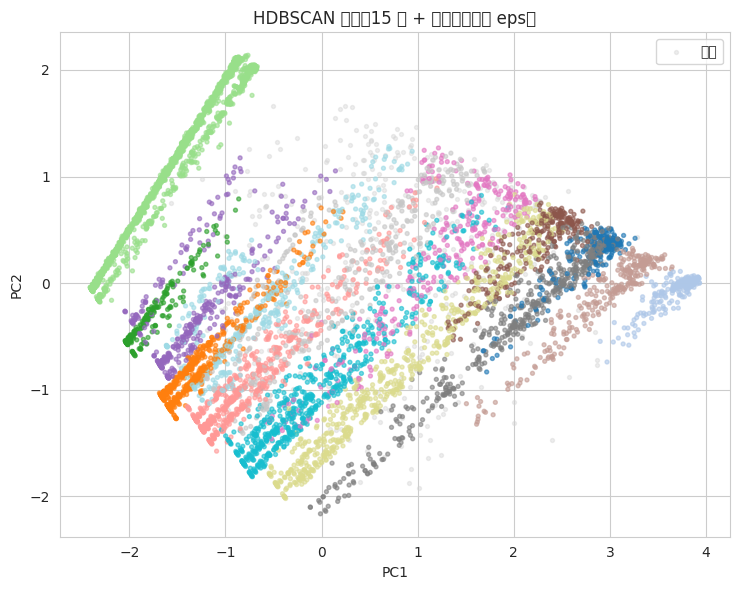


HDBSCAN vs DBSCAN：免調 eps、能處理不同密度的群 → 多數情況首選的密度分群法。


In [31]:
from sklearn.cluster import HDBSCAN

hdb = HDBSCAN(min_cluster_size=200, min_samples=10)
hdb_labels = hdb.fit_predict(Xseg_s)

n_clusters = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
n_noise = int((hdb_labels == -1).sum())
print(f'HDBSCAN 自動找到 {n_clusters} 群，雜訊點 {n_noise} ({n_noise / len(hdb_labels):.1%})')
print('（注意：不用指定 eps，只給了 min_cluster_size=200）')

# 對非雜訊點算輪廓係數
mask = hdb_labels != -1
if mask.sum() > 0 and n_clusters > 1:
    sil = silhouette_score(Xseg_s[mask], hdb_labels[mask])
    print(f'非雜訊點輪廓係數: {sil:.3f}')

# PCA 2D 視覺化 HDBSCAN 結果（雜訊點用灰色）
pca_h = PCA(n_components=2, random_state=RANDOM_STATE)
coords_h = pca_h.fit_transform(Xseg_s)
fig, ax = plt.subplots(figsize=(7.5, 6))
noise_mask = hdb_labels == -1
ax.scatter(coords_h[noise_mask, 0], coords_h[noise_mask, 1],
           c='lightgray', s=8, alpha=0.4, label='雜訊')
ax.scatter(coords_h[~noise_mask, 0], coords_h[~noise_mask, 1],
           c=hdb_labels[~noise_mask], cmap='tab20', s=8, alpha=0.6)
ax.set_title(f'HDBSCAN 分群（{n_clusters} 群 + 雜訊，無需調 eps）')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.legend()
plt.tight_layout(); plt.show()

print('\nHDBSCAN vs DBSCAN：免調 eps、能處理不同密度的群 → 多數情況首選的密度分群法。')

### 5.5 階層式分群 Agglomerative + GMM（軟分群）

兩個常見的補充方法，和 KMeans 對照。

In [32]:
# 階層式（抽樣，因為它是 O(n^2)）
agg = AgglomerativeClustering(n_clusters=K).fit(Xseg_s)
agg_sil = silhouette_score(Xseg_s, agg.labels_)

# GMM：軟分群，回傳機率而非硬標籤
gmm = GaussianMixture(n_components=K, random_state=RANDOM_STATE).fit(Xseg_s)
gmm_labels = gmm.predict(Xseg_s)
gmm_sil = silhouette_score(Xseg_s, gmm_labels)

km_sample = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE).fit(Xseg_s)
km_sil = silhouette_score(Xseg_s, km_sample.labels_)

print('輪廓係數對比（抽樣 8000）：')
print(f'  KMeans        {km_sil:.3f}')
print(f'  Agglomerative {agg_sil:.3f}')
print(f'  GMM           {gmm_sil:.3f}')
print('\nGMM 額外好處：predict_proba 給每客戶屬於各群的機率，可做「邊界客戶」精準行銷。')

輪廓係數對比（抽樣 8000）：
  KMeans        0.406
  Agglomerative 0.344
  GMM           0.322

GMM 額外好處：predict_proba 給每客戶屬於各群的機率，可做「邊界客戶」精準行銷。


### 5.6 PCA 降維視覺化

把 4 維分群特徵壓到 2D，用顏色看 KMeans 分群與流失分布。

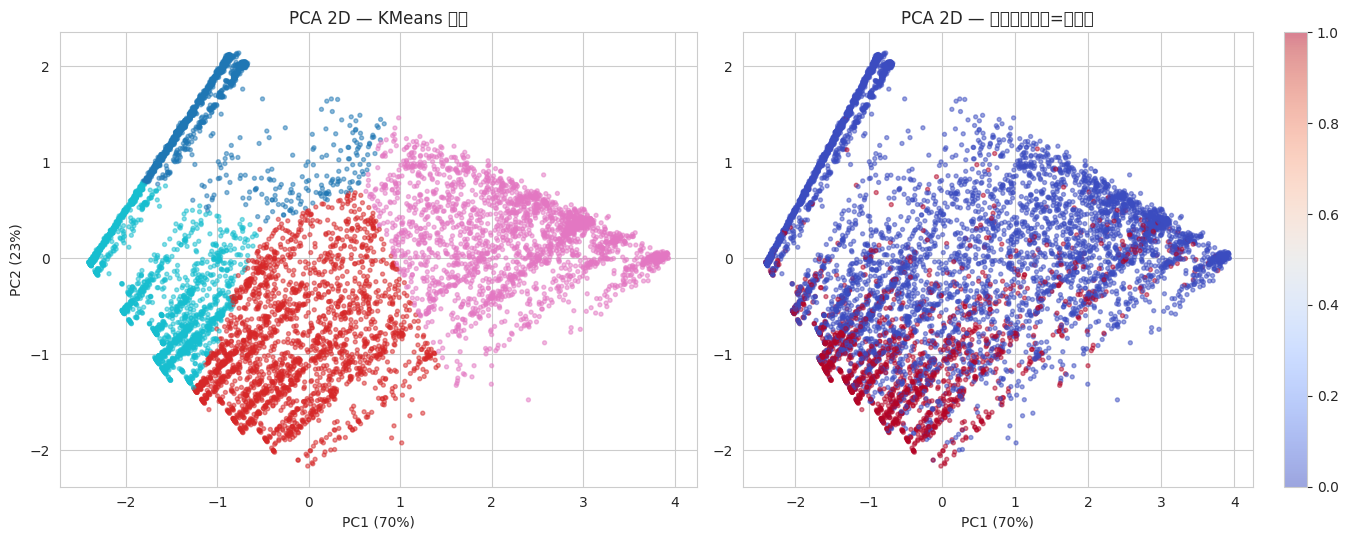

兩主成分共解釋 93% 變異。


In [33]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(Xseg_s)
km_lab = km_sample.labels_

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sc0 = axes[0].scatter(coords[:, 0], coords[:, 1], c=km_lab, cmap='tab10', s=8, alpha=0.5)
axes[0].set_title('PCA 2D — KMeans 分群')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.0%})')

sc1 = axes[1].scatter(coords[:, 0], coords[:, 1], c=churn_s, cmap='coolwarm', s=8, alpha=0.5)
axes[1].set_title('PCA 2D — 實際流失（紅=流失）')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%})')
plt.colorbar(sc1, ax=axes[1])
plt.tight_layout(); plt.show()

print(f'兩主成分共解釋 {pca.explained_variance_ratio_[:2].sum():.0%} 變異。')

## 6. 總結

**監督式**
- 五個模型 ROC-AUC 都落在 ~0.91，boosting（GradientBoost / HistGB / LightGBM）略勝線性模型。
- 若環境沒有 LightGBM，`HistGradientBoostingClassifier` 是同級替代品。
- 最關鍵特徵：**合約類型（Month-to-month）、tenure、付款方式（Electronic check）、加值服務數**。

**非監督式（分群貼標）**
- KMeans 分出可解讀的客群，「高風險客」群流失率遠高於整體 22.5%。
- DBSCAN 在此資料不理想（密度連續）——能講出「為什麼不適合」比硬套更重要。
- GMM 提供軟分群機率，適合鎖定邊界客戶做挽留。

**業務行動**
- 高風險客 → 綁約優惠 / 前 12 個月關懷；推 OnlineSecurity、TechSupport 等黏著型加值服務。
- 用監督式模型輸出流失機率，搭配分群標籤，做差異化挽留。

**模型驗證的嚴謹度（這次補強的重點）**
- **洩漏自檢**：單欄 AUC 最高僅約 0.79（tenure），無單欄逼近滿分 → 0.91 是多訊號疊加，非作弊。
- **交叉驗證**：5-fold AUC 標準差極小（~0.002）→ 分數穩定可信，不是切到好的一刀。
- **PR-AUC 遠低於 ROC-AUC**：不平衡資料下「抓流失客」的真實難度，比 ROC 誠實。
- **機率校準**：boosting 機率需檢查/校準，挽留決策才靠得住。

**延伸討論點**：類別不平衡用 AUC/PR 而非 accuracy；one-hot `drop_first` 防共線性；分群特徵要標準化；DBSCAN 的 eps 敏感性 vs HDBSCAN 免調 eps；XGBoost/LightGBM 都是第三方套件，環境沒有時可用 HistGB 替代；如何證明沒有資料洩漏（單欄 AUC + 拔欄重跑）。